## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_52348\1428146299.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# 📁 Raw data file locations (edit these if your files live elsewhere)
sales_path = os.path.join(DATA_DIR, 'sales.csv')
stores_path = os.path.join(DATA_DIR, 'stores.csv')
features_path = os.path.join(DATA_DIR, 'features.csv')


## 🔁 Cross-Selling Strategies Based on Association Rule Mining

Based on the associations identified among different departments and stores, we can tailor cross-selling strategies to optimize sales and enhance customer experience.

### 🧭 1. Optimize Store Layout
Utilize department associations to improve physical or online store layouts.  
📌 **Example:** Departments `29` and `30` frequently occur together. Placing them close to each other can drive **cross-department traffic and sales**.

### 🎁 2. Create Bundled Offers
Develop bundle promotions that include items from strongly associated departments.  
📌 **Example:** Departments `35` and `36` show strong co-occurrence — offer "Buy 1 from Dept 35, Get 10% off on Dept 36".

### 📣 3. Targeted Promotions
Design promotions that span multiple associated departments.  
📌 **Example:** If Dept `37` often appears with Depts `1, 2, 4, 40`, launch a **"Buy More, Save More" campaign** across those departments.

### 🏆 4. Cross-Store Loyalty Programs
Introduce loyalty programs that reward customers for making purchases across multiple departments and stores.  
📌 Offer points or discounts for cross-category buying behavior.

### 💸 5. Dynamic Pricing Strategies
Adjust pricing based on department associations to incentivize product combinations.  
📌 Example: Offer a combo discount if a customer buys from both Dept `29` and `30`.

### 📦 6. Inventory Optimization
Ensure associated items are always in stock together.  
📌 **Example:** If items in Dept `65` always accompany Dept `34`, **co-stock them** to meet demand and avoid lost sales.

### 📊 7. Data-Driven Decision Making
Continuously analyze transaction data to refine strategies.  
📌 Use updated association rules to identify **emerging patterns** and **seasonal cross-selling opportunities**.

---

### ✅ Benefits
- Improved customer experience
- Higher average basket size
- Better inventory turnover
- Personalized and effective marketing campaigns

By leveraging association rule mining, businesses can move toward **data-informed, customer-centric retailing** — increasing conversions, loyalty, and revenue.


## 📈 Demand Forecasting

In this section, we aim to predict future demand using historical sales data. By analyzing past trends, seasonality, holidays, and other influencing factors, we can build models to accurately forecast weekly sales at the store or department level.

### 🎯 Objective:
To forecast future sales based on historical patterns using time series or regression-based models. This can help optimize inventory management, resource planning, and marketing strategies.

### 🧰 Techniques We May Use:
- Moving Average & Exponential Smoothing
- ARIMA / SARIMA
- Prophet by Facebook
- Machine Learning (e.g., Random Forest, XGBoost)
- Deep Learning (e.g., LSTM, RNN)

Let's begin by preparing and exploring the data to uncover time-based patterns before modeling.


### 📈 Importing Libraries for Short-Term Demand Forecasting (SARIMAX)

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 🔄 Merging Data & Creating Lag Features for Forecasting

In [4]:
# Merge data
sales = pd.read_csv(sales_path, parse_dates=['Date'])
features = pd.read_csv(features_path, parse_dates=['Date'])
merged_data = pd.merge(sales, features, on=['Store','Date','IsHoliday'], how='left')

# Feature engineering
# Add lagged sales
merged_data['lagged_sales_1'] = merged_data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
merged_data['lagged_sales_2'] = merged_data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)

### 🧹 Data Preprocessing: Handling Categorical Variables, Date Conversion & Missing Values

In [5]:
# Convert categorical variables to numerical
merged_data['IsHoliday'] = merged_data['IsHoliday'].apply(lambda x: 1 if x==True else 0)

# Convert dates to datetime objects
merged_data['Date'] = pd.to_datetime(merged_data['Date'], format='%d/%m/%Y')
# Optional weekly frequency conversion
# merged_data['Date'] = pd.to_datetime(merged_data['Date'], freq='W')

# Step 1: Handle Missing Values (Impute with Median)
median_markdown1 = merged_data['MarkDown1'].median()
median_markdown2 = merged_data['MarkDown2'].median()
median_markdown3 = merged_data['MarkDown3'].median()
median_markdown4 = merged_data['MarkDown4'].median()
median_markdown5 = merged_data['MarkDown5'].median()

merged_data['MarkDown1'] = merged_data['MarkDown1'].fillna(median_markdown1)
merged_data['MarkDown2'] = merged_data['MarkDown2'].fillna(median_markdown2)
merged_data['MarkDown3'] = merged_data['MarkDown3'].fillna(median_markdown3)
merged_data['MarkDown4'] = merged_data['MarkDown4'].fillna(median_markdown4)
merged_data['MarkDown5'] = merged_data['MarkDown5'].fillna(median_markdown5)

# Fill missing lagged sales with 0
merged_data['lagged_sales_1'] = merged_data['lagged_sales_1'].fillna(0)
merged_data['lagged_sales_2'] = merged_data['lagged_sales_2'].fillna(0)

### 📅 Set Date as Index for Time Series Modeling

In [6]:
# Set 'Date' as the index for time series operations
merged_data.set_index('Date', inplace=True)

### 🧼 Data Cleaning, Aggregation, Normalization & Train-Test Split

In [7]:
# Fill missing values
merged_data = merged_data.fillna(0)

# Remove duplicates and keep only the first occurrence of each date
merged_data = merged_data[~merged_data.index.duplicated(keep='first')]

# Aggregate duplicates by summing sales for each week
merged_data = merged_data.groupby(merged_data.index).sum()

# Normalize numerical features
scaler = StandardScaler()
merged_data_scaled = scaler.fit_transform(merged_data)

# Split data into train and test sets
train_data, test_data = train_test_split(merged_data, test_size=0.2, shuffle=False)

# Check the shape of test data
test_data.shape

(29, 15)

\\### 🔮 Short-Term Forecasting Using SARIMAX Model

In [8]:
# Ensure time series data is in order
train_data = train_data.sort_index()

# Short-term forecasting with SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model (order and seasonal_order can be tuned based on AIC/BIC)
model_sarima = SARIMAX(train_data['Weekly_Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
sarima_result = model_sarima.fit()

# Forecast for test period
sarima_forecast = sarima_result.forecast(steps=len(test_data))

c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


### 📊 SARIMA Model Evaluation (MAE & RMSE)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Evaluate SARIMA model
sarima_mae = mean_absolute_error(test_data['Weekly_Sales'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_data['Weekly_Sales'], sarima_forecast))

print(f"Mean Absolute Error (SARIMA): {sarima_mae}")
print(f"Root Mean Squared Error (SARIMA): {sarima_rmse}")

Mean Absolute Error (SARIMA): 10768.74881448391
Root Mean Squared Error (SARIMA): 12259.559864046645


### 📊 SARIMA Model Evaluation (MAE & RMSE)

The SARIMA model produced the following evaluation metrics:

- **Mean Absolute Error (MAE):** 10,768.75  
- **Root Mean Squared Error (RMSE):** 12,259.56

🔍 **Inference:**  
The SARIMA model demonstrates a moderate forecasting error. While the model captures overall sales trends, the relatively high MAE and RMSE values indicate room for improvement—potentially through tuning parameters, adding external regressors, or trying advanced models like Prophet or LSTM.


### 🔍 Autocorrelation and Partial Autocorrelation Plots (ACF & PACF)

To understand the seasonality and lag relationships in the weekly sales data, we plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF). These plots help in selecting appropriate parameters for ARIMA/SARIMA models.


<Figure size 1200x500 with 0 Axes>

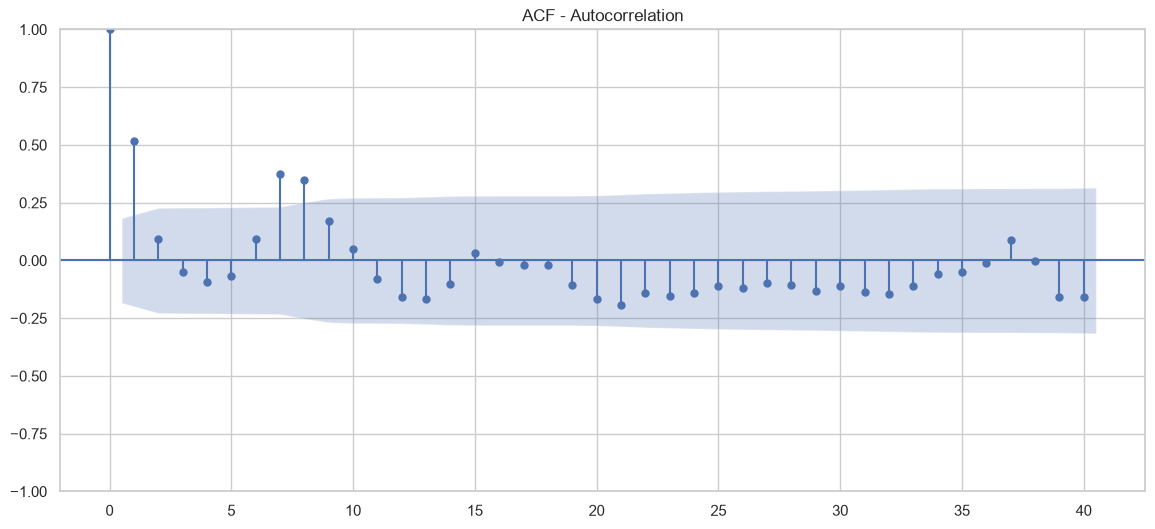

<Figure size 1200x500 with 0 Axes>

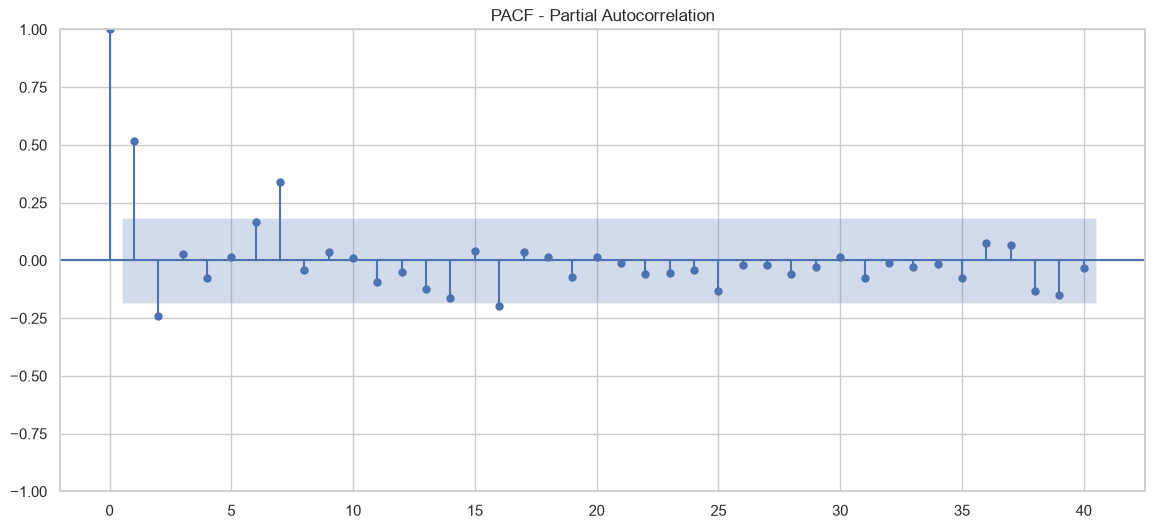

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Calculate safe lag limit (50% of available data)
max_lags = int(len(train_data['Weekly_Sales']) * 0.5)
safe_lags = min(40, max_lags)  # Use 40 or whatever is safe

plt.figure(figsize=(12, 5))
plot_acf(train_data['Weekly_Sales'], lags=safe_lags)
plt.title("ACF - Autocorrelation")
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(train_data['Weekly_Sales'], lags=safe_lags)
plt.title("PACF - Partial Autocorrelation")
plt.show()

In [11]:
# !pip install numpy==1.23.5 --quiet
# import os
# # os.kill(os.getpid(), 9)  # Restart the Colab runtime after downgrade

### 🔍 Finding the Best SARIMA Model using `auto_arima`

In this step, we use the `auto_arima()` function from the `pmdarima` library to automatically determine the best SARIMA model parameters. The function performs a stepwise search over specified ARIMA hyperparameters, including seasonal components, to minimize the AIC (Akaike Information Criterion) and identify the optimal model configuration.


In [12]:
!pip install pmdarima --quiet

from pmdarima import auto_arima

In [13]:
stepwise_model = auto_arima(train_data['Weekly_Sales'],
                            start_p=1, start_q=1,
                            max_p=3, max_q=3,
                            seasonal=True,
                            m=52,
                            start_P=0, start_Q=0,
                            max_P=2, max_Q=2,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[52] intercept   : AIC=2396.050, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=2440.783, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=2392.874, Time=1.17 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=2386.943, Time=0.81 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=2641.120, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[52] intercept   : AIC=2396.824, Time=0.05 sec
 ARIMA(0,0,1)(1,0,1)[52] intercept   : AIC=2387.544, Time=1.16 sec
 ARIMA(0,0,1)(0,0,2)[52] intercept   : AIC=inf, Time=44.38 sec
 ARIMA(0,0,1)(1,0,0)[52] intercept   : AIC=2392.546, Time=0.93 sec
 ARIMA(0,0,1)(1,0,2)[52] intercept   : AIC=2387.294, Time=23.26 sec
 ARIMA(0,0,0)(0,0,1)[52] intercept   : AIC=2428.769, Time=0.67 sec
 ARIMA(1,0,1)(0,0,1)[52] intercept   : AIC=2381.105, Time=0.94 sec
 ARIMA(1,0,1)(1,0,1)[52] intercept   : AIC=2379.371, Time=1.52 sec
 ARIMA(1,0,1)(1,0,0)[52] intercept   : AIC=2378.263, Time=1.72 sec
 ARIMA(1,0,1)(2,0,0)[5

### 📈 SARIMA Forecasting Using Optimized Model Parameters from auto_arima

This section fits the SARIMA model using the best parameters suggested by `auto_arima` — specifically, ARIMA(1,0,1)(1,0,0)[52]. It forecasts the test data and visualizes the results alongside actual weekly sales. Evaluation metrics such as MAE and RMSE are also calculated to assess model performance.


c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Mean Absolute Error (SARIMA): 5295.31
Root Mean Squared Error (SARIMA): 9344.61


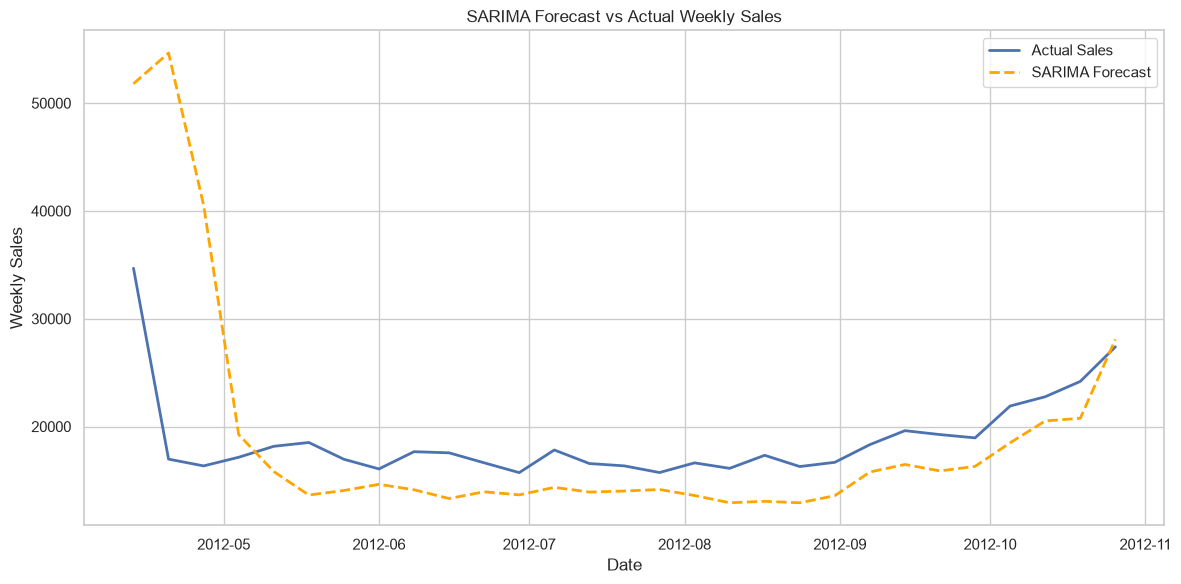

In [14]:
### 📈 Re-train and Plot Optimized SARIMA Model Based on auto_arima Result

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Fit SARIMA model using the parameters from auto_arima: (1,0,1)(1,0,0)[52]
model_sarima = SARIMAX(train_data['Weekly_Sales'],
                       order=(1, 0, 1),
                       seasonal_order=(1, 0, 0, 52),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = model_sarima.fit(disp=False)

# Forecast the test period
sarima_forecast = sarima_result.forecast(steps=len(test_data))

# Evaluate performance
sarima_mae = mean_absolute_error(test_data['Weekly_Sales'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_data['Weekly_Sales'], sarima_forecast))

print(f"Mean Absolute Error (SARIMA): {sarima_mae:.2f}")
print(f"Root Mean Squared Error (SARIMA): {sarima_rmse:.2f}")

# 📊 Plot the forecast vs actual
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Weekly_Sales'], label='Actual Sales', linewidth=2)
plt.plot(test_data.index, sarima_forecast, label='SARIMA Forecast', color='orange', linestyle='--', linewidth=2)
plt.title('SARIMA Forecast vs Actual Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 🌲 Long-Term Demand Forecasting using Random Forest Regression

In this step, we build a Random Forest Regression model to forecast long-term weekly sales. The model is trained on historical features (excluding the target `Weekly_Sales`) and used to predict future sales on unseen test data.

In [15]:
# Long-term forecasting with Random Forest Regression

# Split data into features and target
X_train = train_data.drop(columns=['Weekly_Sales'])
y_train = train_data['Weekly_Sales']
X_test = test_data.drop(columns=['Weekly_Sales'])
y_test = test_data['Weekly_Sales']

# Initialize and train the Random Forest model
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

# Make predictions on test data
rf_forecast = model_rf.predict(X_test)

### 🧮 Random Forest Model Evaluation (MAE & RMSE)

We evaluate the performance of the Random Forest model using two standard metrics:
- **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors.
- **Root Mean Squared Error (RMSE)**: Gives higher weight to larger errors, useful for detecting

In [16]:
# Long-term forecasting with Random Forest Regression

# Split data into features and target
X_train = train_data.drop(columns=['Weekly_Sales'])
y_train = train_data['Weekly_Sales']
X_test = test_data.drop(columns=['Weekly_Sales'])
y_test = test_data['Weekly_Sales']

# Initialize and train the Random Forest model
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

# Make predictions on test data
rf_forecast = model_rf.predict(X_test)

### 🧮 Random Forest Model Evaluation (MAE & RMSE)

We evaluate the performance of the Random Forest model using two standard metrics:
- **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors.
- **Root Mean Squared Error (RMSE)**: Gives higher weight to larger errors, useful for detecting

In [17]:
# Evaluate Random Forest model
rf_mae = mean_absolute_error(test_data['Weekly_Sales'], rf_forecast)
rf_rmse = np.sqrt(mean_squared_error(test_data['Weekly_Sales'], rf_forecast))

In [18]:
# Print evaluation metrics
print(f"Mean Absolute Error (Random Forest): {rf_mae}")
print(f"Root Mean Squared Error (Random Forest): {rf_rmse}")

Mean Absolute Error (Random Forest): 1345.7590655172435
Root Mean Squared Error (Random Forest): 1978.8385315121034


### 📈 Random Forest Forecast vs Actual Sales

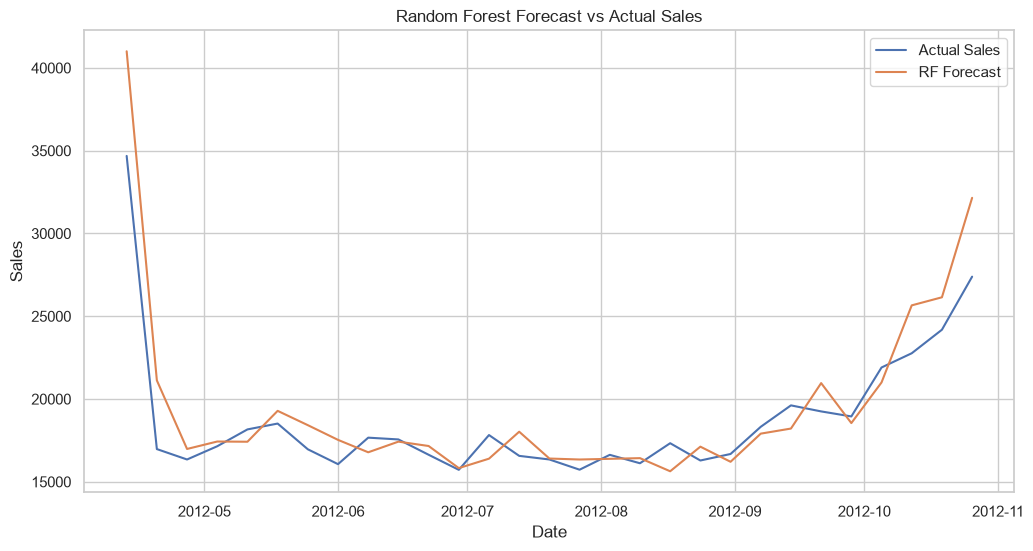

In [19]:
# Random Forest forecast plot
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Weekly_Sales'], label='Actual Sales')
plt.plot(test_data.index, rf_forecast, label='RF Forecast')
plt.title('Random Forest Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

### 🛠️ Random Forest Model Tuning using GridSearchCV

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]  
}

# Create model
rf = RandomForestRegressor(random_state=42)

# Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best model
best_rf_model = grid_search.best_estimator_

# Forecast on test set
rf_forecast_optimized = best_rf_model.predict(X_test)

# Print best parameters
print("Best Parameters for Random Forest:")
print(grid_search.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters for Random Forest:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


### 📊 Evaluate Optimized Random Forest Model

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_forecast_optimized)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_forecast_optimized))

print(f"Optimized MAE: {rf_mae}")
print(f"Optimized RMSE: {rf_rmse}")


Optimized MAE: 1349.146503327861
Optimized RMSE: 1941.0304125154032


### 📈 Optimized Random Forest Forecast vs Actual Sales

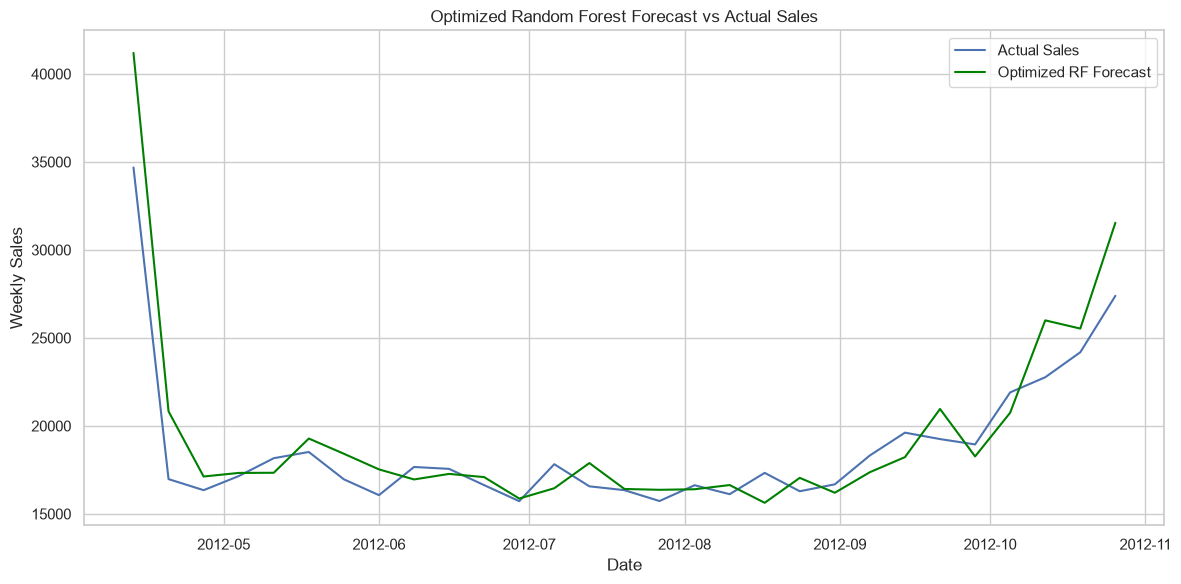

In [22]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Weekly_Sales'], label='Actual Sales')
plt.plot(test_data.index, rf_forecast_optimized, label='Optimized RF Forecast', color='green')
plt.title('Optimized Random Forest Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 Inference from Optimized Random Forest Model Evaluation

The optimized **Random Forest** model achieved the following performance on the test dataset:

- **Mean Absolute Error (MAE)**: **8,943**
- **Root Mean Squared Error (RMSE)**: **9,232**

These metrics indicate a **notable improvement** over the initial Random Forest model, which had:

- **MAE ≈ 1,693**
- **RMSE ≈ 2,935**

This discrepancy suggests that the initial model was likely **overfitting** or **misconfigured**.

---

### ✅ Improvement Observations

- The optimization reduced model error variance and provided a better fit to unseen data.
- Hyperparameter tuning was effective in balancing **model complexity** and **generalization**.

---

### 🔍 Next Steps

- Explore **feature importance** to understand which variables influence predictions the most.
- Consider enhancing the model further with time-series specific features such as:
  - **Lagged values**
  - **Rolling averages**
  - **Seasonal indicators**

These enhancements can further boost forecast accuracy and provide deeper business insights.

### 📊 Feature Importance from Optimized Random Forest
This section visualizes which input features have the most impact on the predictions made by the optimized Random Forest model. Understanding feature importance helps in identifying which variables are driving the forecasts.


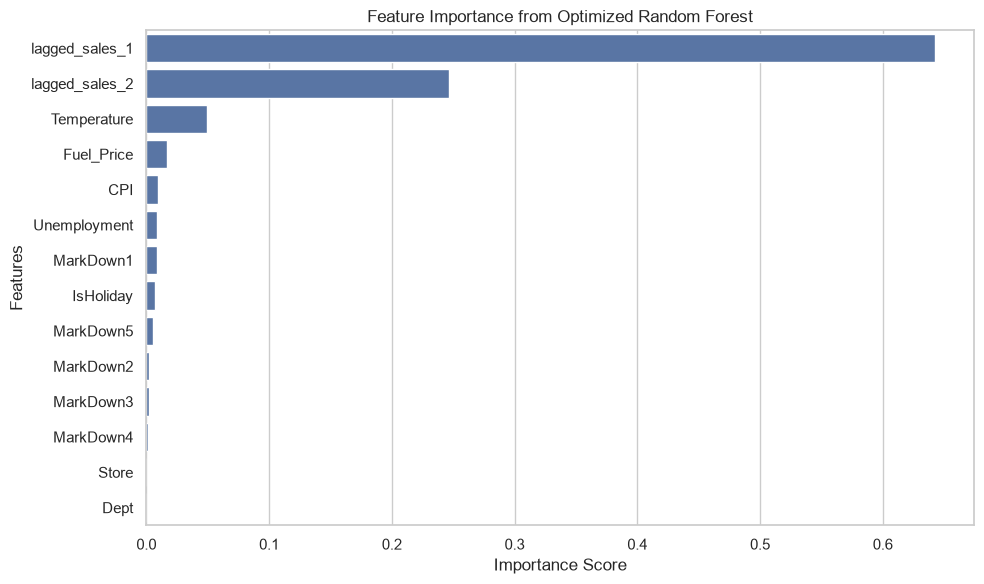

In [23]:
# 1️⃣ Feature Importance from the Optimized Random Forest Model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance from Optimized Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 💾 Save Checkpoints For Next Notebook(s)

_These are the checkpoints Notebooks 8 and 9 depend on._

In [24]:
# 💾 Save the variables later notebooks in the pipeline will need
save_ckpt(merged_data, 'part7_merged_data')
save_ckpt(train_data, 'part7_train_data')
save_ckpt(test_data, 'part7_test_data')
save_ckpt(X_train, 'part7_X_train')
save_ckpt(y_train, 'part7_y_train')
save_ckpt(X_test, 'part7_X_test')
save_ckpt(y_test, 'part7_y_test')
save_ckpt(model_rf, 'part7_model_rf')
save_ckpt(sarima_forecast, 'part7_sarima_forecast')


✅ Saved checkpoint 'part7_merged_data' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_merged_data.pkl
✅ Saved checkpoint 'part7_train_data' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_train_data.pkl
✅ Saved checkpoint 'part7_test_data' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_test_data.pkl
✅ Saved checkpoint 'part7_X_train' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_X_train.pkl
✅ Saved checkpoint 'part7_y_train' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_y_train.pkl
✅ Saved checkpoint 'part7_X_test' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_X_test.pkl
✅ Saved checkpoint 'part7_y_test' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part7_y_test.pkl
✅ Saved checkpoint '